In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

import os

In [2]:
dataset_dir = "dataset"

In [3]:
csv_tables = [
    "application_train.csv",
    "bureau_balance.csv",
    "bureau.csv",
    "credit_card_balance.csv",
    "installments_payments.csv",
    "POS_CASH_balance.csv",
    "previous_application.csv",
    "sample_submission.csv"
]

(
    applications_df,
    bureau_balance_df,
    bureau_df,
    credit_card_balance_df,
    installments_payments_df,
    POS_CASH_balance_df,
    previous_application_df,
    sample_submission_df
) = [pd.read_csv(os.path.join(dataset_dir, table)) for table in csv_tables]

## Exploratory Data Analysis (EDA)
In this section, we will examine the main data table *application_train.csv*.

We are dealing with an imbalanced class problem.

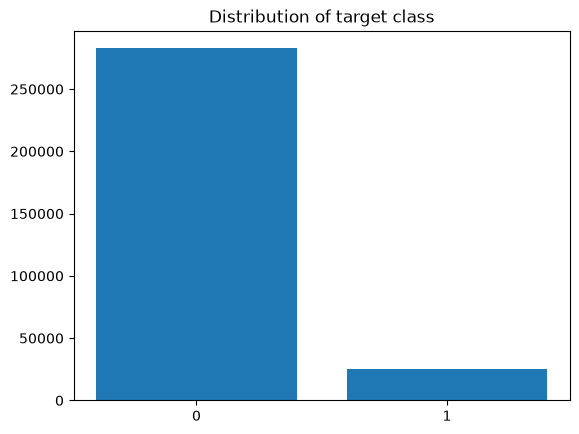

In [4]:
target_counts = applications_df["TARGET"].value_counts().tolist()

plt.bar([0, 1], target_counts)
plt.xticks([0, 1])
plt.title("Distribution of target class")
plt.show()

In [5]:
def missing_values(df):
    missing_count = df.isna().sum()
    missing_percentage = missing_count / len(df) * 100

    missing_df = pd.concat([missing_count, missing_percentage], axis=1)
    missing_df.columns=["Missing Values", "Missing Values (%)"]
    missing_df = missing_df.sort_values(by="Missing Values (%)", ascending=False)
    
    return missing_df

In [6]:
missing_values(applications_df).head(20)

,Missing Values,Missing Values (%)
COMMONAREA_AVG,214865,69.872297
COMMONAREA_MODE,214865,69.872297
COMMONAREA_MEDI,214865,69.872297
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_AVG,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953
LIVINGAPARTMENTS_MODE,210199,68.354953


In [7]:
applications_df.dtypes.value_counts()

float64    65
int64      41
str        16
Name: count, dtype: int64

In [8]:
applications_df["DAYS_EMPLOYED"].sort_values().value_counts()

DAYS_EMPLOYED
 365243    55374
-200         156
-224         152
-230         151
-199         151
           ...  
-23            1
-10            1
-7             1
-5             1
-1             1
Name: count, Length: 12574, dtype: int64

In [9]:
applications_df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


## Feature engineering

The `agg_numeric_columns` function creates a new DataFrame with aggregated numeric columns of the given DataFrame.

In [4]:
def agg_numeric_columns(df, groupby_columns, metrics=["count", "mean", "sum", "min", "max"], exclude_columns=None):
    exclude_columns = exclude_columns or []

    # Find all numeric columns that are not used for grouping
    numeric_columns = df.select_dtypes(include="number").columns.tolist()
    numeric_columns = [c for c in numeric_columns if c not in groupby_columns and c not in exclude_columns]

    if not numeric_columns:
        return df[groupby_columns].drop_duplicates().reset_index(drop=True)
    
    # Compute the aggregations and return a multi-index DataFrame
    multi_index_agg = df.groupby(groupby_columns)[numeric_columns].agg(metrics)

    # Flatten the DataFrame
    agg_df = pd.DataFrame({
        f"{column}_{agg}": multi_index_agg[(column, agg)]
        for column, agg in multi_index_agg.columns
    }).reset_index()

    # Only "count"/"sum" of an empty group are 0, for "mean"/"min"/"max"
    # a missing value means "no data", so leave it as NaN to avoid misleading the model.
    fill_zero_columns = [
        f"{column}_{agg}"
        for column, agg in multi_index_agg.columns
        if agg in ("count", "sum")
    ]
    agg_df[fill_zero_columns] = agg_df[fill_zero_columns].fillna(0)

    return agg_df

The `agg_categorical_columns` function creates a new DataFrame with aggregated categorical
columns of the given DataFrame.

In [5]:
def agg_categorical_columns(df, groupby_columns, exclude_columns=None):
    exclude_columns = exclude_columns or []
    categorical_columns = [
        c for c in df.select_dtypes(include="str").columns
        if c not in groupby_columns and c not in exclude_columns
    ]

    if not categorical_columns:
        return df[groupby_columns].drop_duplicates().reset_index(drop=True)
    
    one_hot_df = pd.get_dummies(df[groupby_columns + categorical_columns])
    multi_index_agg = one_hot_df.groupby(groupby_columns).agg(["sum", "mean"])
    multi_index_agg = multi_index_agg.rename(columns={"sum": "count", "mean": "count_norm"}, level=1)
    
    agg_df = pd.DataFrame({
        f"{column}_{agg}": multi_index_agg[(column, agg)]
        for column, agg in multi_index_agg.columns
    }).reset_index()
    
    return agg_df

A method that aggregates both numeric and categorical features of a dataframe.

In [6]:
def agg_columns(df, groupby_columns, exclude_columns=None):
    agg_numeric_df = agg_numeric_columns(df=df, groupby_columns=groupby_columns, exclude_columns=exclude_columns)
    agg_categorical_df = agg_categorical_columns(df=df, groupby_columns=groupby_columns, exclude_columns=exclude_columns)

    return pd.merge(agg_numeric_df, agg_categorical_df, on=groupby_columns)

### The bureau tables

Aggregate the *bureau_balance* table and merge it with the *bureau* table

In [7]:
agg_bureau_balance_df = agg_columns(bureau_balance_df, groupby_columns=["SK_ID_BUREAU"])
merged_bureau_bureau_balance_df = pd.merge(bureau_df, agg_bureau_balance_df, on="SK_ID_BUREAU", how="left")

Aggregate the merged table and merge it with the main *applications* table.

In [8]:
agg_merged_bureau_bureau_balance_df = agg_columns(
    merged_bureau_bureau_balance_df,
    groupby_columns=["SK_ID_CURR"],
    exclude_columns=["SK_ID_BUREAU"]
)
merged_applications_df = pd.merge(applications_df, agg_merged_bureau_bureau_balance_df, on="SK_ID_CURR", how="left")

In [9]:
merged_applications_df

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,CREDIT_TYPE_Microloan_count,CREDIT_TYPE_Microloan_count_norm,CREDIT_TYPE_Mobile operator loan_count,CREDIT_TYPE_Mobile operator loan_count_norm,CREDIT_TYPE_Mortgage_count,CREDIT_TYPE_Mortgage_count_norm,CREDIT_TYPE_Real estate loan_count,CREDIT_TYPE_Real estate loan_count_norm,CREDIT_TYPE_Unknown type of loan_count,CREDIT_TYPE_Unknown type of loan_count_norm
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### The Home Credit tables

Aggregate the *POS_CASH_balance* table and merge it with the *applications* table

In [10]:
agg_POS_CASH_balance_df = agg_columns(
    POS_CASH_balance_df,
    groupby_columns=["SK_ID_PREV", "SK_ID_CURR"]
).drop(columns=["SK_ID_PREV"])
merged_applications_df = pd.merge(merged_applications_df, agg_POS_CASH_balance_df, on="SK_ID_CURR", how="left")

In [11]:
merged_applications_df

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,NAME_CONTRACT_STATUS_Completed_count,NAME_CONTRACT_STATUS_Completed_count_norm,NAME_CONTRACT_STATUS_Demand_count,NAME_CONTRACT_STATUS_Demand_count_norm,NAME_CONTRACT_STATUS_Returned to the store_count,NAME_CONTRACT_STATUS_Returned to the store_count_norm,NAME_CONTRACT_STATUS_Signed_count,NAME_CONTRACT_STATUS_Signed_count_norm,NAME_CONTRACT_STATUS_XNA_count,NAME_CONTRACT_STATUS_XNA_count_norm
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,1.0,0.125000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,1.0,0.125000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,1.0,0.250000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
818399,456255,0,Cash loans,F,N,N,0,157500.0,675000.0,49117.5,...,1.0,0.111111,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
818400,456255,0,Cash loans,F,N,N,0,157500.0,675000.0,49117.5,...,1.0,0.090909,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
818401,456255,0,Cash loans,F,N,N,0,157500.0,675000.0,49117.5,...,1.0,0.200000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
818402,456255,0,Cash loans,F,N,N,0,157500.0,675000.0,49117.5,...,1.0,0.040000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Aggregate the *installments_payment* table and merge it with the *previous_application* table

In [12]:
agg_installments_payments_df = agg_columns(
    installments_payments_df,
    groupby_columns=["SK_ID_PREV", "SK_ID_CURR"]
).drop(columns=["SK_ID_PREV"])
merged_applications_df = pd.merge(merged_applications_df, agg_installments_payments_df, on="SK_ID_CURR", how="left")

In [13]:
merged_applications_df

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,AMT_INSTALMENT_count,AMT_INSTALMENT_mean,AMT_INSTALMENT_sum,AMT_INSTALMENT_min,AMT_INSTALMENT_max,AMT_PAYMENT_count,AMT_PAYMENT_mean,AMT_PAYMENT_sum,AMT_PAYMENT_min,AMT_PAYMENT_max
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,19.0,11559.247105,219625.695,9251.775,53093.745,19.0,11559.247105,219625.695,9251.775,53093.745
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,7.0,164425.332857,1150977.330,98356.995,560835.360,7.0,164425.332857,1150977.330,98356.995,560835.360
2,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,12.0,6731.115000,80773.380,6662.970,6737.310,12.0,6731.115000,80773.380,6662.970,6737.310
3,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,6.0,64518.990000,387113.940,64275.615,64567.665,6.0,64518.990000,387113.940,64275.615,64567.665
4,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,7.0,164425.332857,1150977.330,98356.995,560835.360,7.0,164425.332857,1150977.330,98356.995,560835.360
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3503865,456255,0,Cash loans,F,N,N,0,157500.0,675000.0,49117.5,...,9.0,15610.860000,140497.740,11314.170,49984.380,9.0,14353.730000,129183.570,2065.950,49984.380
3503866,456255,0,Cash loans,F,N,N,0,157500.0,675000.0,49117.5,...,10.0,13218.228000,132182.280,11090.835,32364.765,10.0,13218.228000,132182.280,11090.835,32364.765
3503867,456255,0,Cash loans,F,N,N,0,157500.0,675000.0,49117.5,...,5.0,63086.625000,315433.125,16400.610,249830.685,5.0,56526.381000,282631.905,34.965,249830.685
3503868,456255,0,Cash loans,F,N,N,0,157500.0,675000.0,49117.5,...,29.0,58353.824483,1692260.910,27489.690,615229.515,29.0,77639.786379,2251553.805,110.880,669251.655


Aggregate the *credit_card_balance* table and merge it with the *previous_application* table

In [ ]:
agg_credit_card_balance_df = agg_columns(
    credit_card_balance_df,
    groupby_columns=["SK_ID_PREV", "SK_ID_CURR"]
).drop(columns=["SK_ID_PREV"])
merged_applications_df = pd.merge(merged_applications_df, credit_card_balance_df, on="SK_ID_CURR", how="left")